## **Biological Databases**

<h3> Protein Data Bank (PDB)

PDB is an open database of three-dimensional structures of biological macromolecules, such as proteins, DNA and RNA, obtained by experimental methods, including: X-ray crystallography or NMR spectroscopy.

In [9]:
from urllib.request import urlopen #module to open the URL

def downloadPDBasList(pdbId):
    response = urlopen(f'https://files.rcsb.org/download/{pdbId}.pdb') # we open the connection
    data = response.read().decode('utf-8') # coding method
    t = data.split('\n') # each line will be a separate list item
    return t

In [11]:
t = downloadPDBasList("1UBQ") # we collect a protein with a given ID

# We display the first 10 lines
n = 0
for line in t:
    print(line)
    n += 1
    if n >= 10:
        break

HEADER    CHROMOSOMAL PROTEIN                     02-JAN-87   1UBQ              
TITLE     STRUCTURE OF UBIQUITIN REFINED AT 1.8 ANGSTROMS RESOLUTION            
COMPND    MOL_ID: 1;                                                            
COMPND   2 MOLECULE: UBIQUITIN;                                                 
COMPND   3 CHAIN: A;                                                            
COMPND   4 ENGINEERED: YES                                                      
SOURCE    MOL_ID: 1;                                                            
SOURCE   2 ORGANISM_SCIENTIFIC: HOMO SAPIENS;                                   
SOURCE   3 ORGANISM_COMMON: HUMAN;                                              
SOURCE   4 ORGANISM_TAXID: 9606                                                 


### **Task 1**

Define a function that, for a selected protein chain, determines the geometric distance between the first and last atoms. For example, for $1UBQ$, for the $A$ chain it will be the distance between the point $P_1(27.34, 24.43, 2.614)$ and $P_2(40.862,39.575,36.251)$ and it is $39.30$ $A$.

$d = \sqrt{(x_1-x_2)^2+(y_1-y_2)^2+(z_1-z_2)^2}$

In [12]:
def getAtomNumbers(atom_info: str) -> list:
    atom_numbers = []
    for line in atom_info:
        if line[0:4] == "ATOM":
            atom_line = line.split()
            atom_numbers.append(atom_line[1])
    return atom_numbers

def atomsCoordinates(atom_info: str, number: int) -> list:
    for line in atom_info:
        if line[0:4] == "ATOM":
            splitted_line = line.split()
            if int(splitted_line[1]) == number:
                x = float(splitted_line[6])
                y = float(splitted_line[7])
                z = float(splitted_line[8])
                return [x, y, z]
            
def atomsDistance(atom1: list, atom2: list) -> float:
    return ((atom1[0] - atom2[0]) ** 2 + (atom1[1] - atom2[1]) ** 2 + (atom1[2] - atom2[2]) ** 2) ** 0.5

atoms_numbers = getAtomNumbers(t)

first_atom_number = int(atoms_numbers[0])
last_atom_number = int(atoms_numbers[-1])

first_coordinates = atomsCoordinates(t, first_atom_number)
last_coordinates = atomsCoordinates(t, last_atom_number)

print(f"Distance between atoms is {round((atomsDistance(first_coordinates, last_coordinates)), 1)} Å")

Distance between atoms is 39.3 Å


### **PubMed**

PubMed is a database of scientific publications in the field of medicine, biology, bioinformatics and related sciences, maintained by NCBI (National Center for Biotechnology Information).

**Search for works by a given author**

In [13]:
from urllib.request import urlopen
from urllib.parse import urlencode 
from lxml import etree  #module to open XML files


author_name = "Krzysztof Murzyn"
base_url = "https://eutils.ncbi.nlm.nih.gov/entrez/eutils/esearch.fcgi?"
url = base_url+ urlencode({"db": "pubmed", "term": author_name+"[author]", "retmax": 30})

response = urlopen(url)
resultxml = response.read()
xml = etree.XML(resultxml)

In [15]:
tags = list({elem.tag for elem in xml.iter()})

print(tags)

['QueryTranslation', 'IdList', 'From', 'eSearchResult', 'Count', 'TranslationSet', 'Translation', 'Id', 'RetMax', 'RetStart', 'To']


In [ ]:
resultelements = xml.xpath("//Id")

for elem in resultelements:
    print(elem.text)

39789967
39246722
39141478
38750995
37592849
37416056
37350851
36464767
35723299
32940993
30504221
27902406
26825705
26718149
25867074
25296168
24660117
24286298
23527010
22428146
22284390
20506323
19909337
19199693
17985365
20408622
16395663
15652158
15556990
14594994


**Wyszukiwanie pracy po ID**

In [16]:
from urllib.request import urlopen
from lxml import etree

PMID = '33713823'
baseurl = "https://eutils.ncbi.nlm.nih.gov/entrez/eutils/efetch.fcgi?"
query = "db=pubmed&id="+PMID+"&format=xml"    

url = baseurl+query
f = urlopen(url) 
resultxml = f.read() 
xml = etree.XML(resultxml) 

tags = list({elem.tag for elem in xml.iter()}) # what can I find out about this job?
print(tags)

['MeshHeadingList', 'JournalIssue', 'Title', 'ArticleIdList', 'ForeName', 'Year', 'Month', 'ELocationID', 'LastName', 'PublicationType', 'MedlineCitation', 'ArticleTitle', 'ArticleDate', 'MedlineTA', 'EndPage', 'PubDate', 'AffiliationInfo', 'MedlineJournalInfo', 'ISSNLinking', 'Initials', 'MedlinePgn', 'NlmUniqueID', 'Pagination', 'DateCompleted', 'DescriptorName', 'CopyrightInformation', 'ISSN', 'ISOAbbreviation', 'Minute', 'DateRevised', 'Language', 'PubmedData', 'PubMedPubDate', 'Hour', 'PMID', 'Abstract', 'Author', 'PublicationStatus', 'Day', 'Keyword', 'Article', 'Issue', 'PublicationTypeList', 'CitationSubset', 'AuthorList', 'MeshHeading', 'PubmedArticleSet', 'Country', 'KeywordList', 'AbstractText', 'PubmedArticle', 'Journal', 'Volume', 'History', 'ArticleId', 'Affiliation', 'StartPage']


In [17]:
resultelements= xml.xpath("//ArticleTitle") 

for element in resultelements:
    print(element.text)

The robustness of the chaos game representation to mutations and its application in free-alignment methods.


In [18]:
resultelements= xml.xpath("//AbstractText") 

for element in resultelements:
    print(element.text)

Numerical representation of biological sequences plays an important role in bioinformatics and has many practical applications. One of the most popular approaches is the chaos game representation. In this paper, the authors propose a novel look into chaos game construction - an analytical description of this procedure. This type enables to build more general number sequences using different weight functions. The authors suggest three conditions that these functions should hold. Additionally, they present some criteria to compare them and check whether they provide a unique representation. One of the most important advantages of our approach is the possibility to construct such a description that is less sensitive to mutations and as a result, give more reliable values for free-alignment phylogenetic trees constructions. Finally, the authors applied the DFT method using four types of functions and compared the obtained results using the BLAST tool.


Note: 
- when downloading a larger number of records, it is worth using time.sleep(1) from the time module
- when saving to a file, it is worth specifying the encoding method due to the variety of characters (encoding="utf-8")

### **Task 2**
    
From the PubMed database, download and save to a text file all titles of publications (each in a new line) authored (or co-authored) by Krzysztof Murzyn.
    
You can complete the task in steps:
- download IDs of all works,
- download all titles for each ID (you can save them to a list)
- save data to a text file

In [20]:
from urllib.request import urlopen
from urllib.parse import urlencode 
from lxml import etree 
import time

author_name = "Krzysztof Murzyn"
base_url = "https://eutils.ncbi.nlm.nih.gov/entrez/eutils/esearch.fcgi?"
url = base_url + urlencode({"db": "pubmed", "term": author_name+"[author]", "retmax": 50}) 

search_response = urlopen(url)
search_xml_data = search_response.read()
search_xml = etree.XML(search_xml_data)

id_elements = search_xml.xpath("//Id")
id_list = [elem.text for elem in id_elements]

baseurl = "https://eutils.ncbi.nlm.nih.gov/entrez/eutils/efetch.fcgi?"
all_titles = [] 

with open("titles.txt", "w", encoding="utf-8") as titles_file:
    for pmid in id_list:
        print(f"Downloading: {pmid}")
        query = "db=pubmed&id=" + pmid + "&format=xml"
        url = baseurl + query
        
        response = urlopen(url)
        xml_data = response.read()
        xml = etree.XML(xml_data)

        title_elements = xml.xpath("//ArticleTitle")

        if title_elements and title_elements[0].text:
            title = title_elements[0].text
            all_titles.append(title)
        
        time.sleep(0.4)

    for title in all_titles:
        titles_file.write(title + "\n")
        
print("Download complete.")

Downloading: 41452100
Downloading: 39789967
Downloading: 39246722
Downloading: 39141478
Downloading: 38750995
Downloading: 37592849
Downloading: 37416056
Downloading: 37350851
Downloading: 36464767
Downloading: 35723299
Downloading: 32940993
Downloading: 30504221
Downloading: 27902406
Downloading: 26825705
Downloading: 26718149
Downloading: 25867074
Downloading: 25296168
Downloading: 24660117
Downloading: 24286298
Downloading: 23527010
Downloading: 22428146
Downloading: 22284390
Downloading: 20506323
Downloading: 19909337
Downloading: 19199693
Downloading: 17985365
Downloading: 20408622
Downloading: 16395663
Downloading: 15652158
Downloading: 15556990
Downloading: 14594994
Downloading: 14515159
Downloading: 12774216
Download complete.


### **Task 3**
    
How many times did the word "molecule" appear in all abstracts of works authored or co-authored by Krzysztof Murzyn?

In [21]:
from urllib.request import urlopen
from urllib.parse import urlencode 
from lxml import etree 
import time

author_name = "Krzysztof Murzyn"
base_url = "https://eutils.ncbi.nlm.nih.gov/entrez/eutils/esearch.fcgi?"
url = base_url + urlencode({"db": "pubmed", "term": author_name+"[author]", "retmax": 50}) 

search_response = urlopen(url)
search_xml_data = search_response.read()
search_xml = etree.XML(search_xml_data)

id_elements = search_xml.xpath("//Id")
id_list = [elem.text for elem in id_elements]

baseurl = "https://eutils.ncbi.nlm.nih.gov/entrez/eutils/efetch.fcgi?"
molecule_count = 0
word = "molecule"

for pmid in id_list:
    query = "db=pubmed&id=" + pmid + "&format=xml"
    url = baseurl + query
    
    response = urlopen(url)
    xml_data = response.read()
    xml = etree.XML(xml_data)

    abstract_elements = xml.xpath("//AbstractText")

    abstract = ""
    for elem in abstract_elements:
        if elem.text:
            abstract = abstract + " " + elem.text
    
    if abstract:
        count = abstract.lower().count(word)
        if count > 0:
            print(f"Downloading from: {pmid}")
        molecule_count += count

    time.sleep(0.4)

print(f"Word '{word}' occurred {molecule_count} times.")


Word 'molecule' occurred 25 times.


### **Task 4**
    
- Open the works.txt file containing the IDs of the selected works from PubMed. Download MeshTerms (TAG: DescriptorName) for each job.

- The result should be a list of meshterms lists. Convert all letters to lowercase.

- Transform the created list into a vector form (TF-IDF technique).

- Standardize the data, then apply the PCA method for dimension reduction and present the results in 2D. Comment on the results obtained. How many thematic groups do you see?

PMID 9349269 (MeSH): ['amino acid sequence', 'arabidopsis', 'brassica', 'chromosome mapping', 'dna, complementary', 'dna, plant', 'gene expression regulation, plant', 'genes, plant', 'germination', 'glycoproteins', 'molecular sequence data', 'oxidoreductases', 'phylogeny', 'plant leaves', 'plant proteins', 'protein structure, secondary', 'rna, messenger', 'rna, plant', 'seeds', 'sequence analysis, dna', 'sequence homology, amino acid']
PMID 23412914 (MeSH): ['anti-inflammatory agents', 'antibodies, monoclonal, humanized', 'bevacizumab', 'dexamethasone', 'fractionation, field flow', 'humans', 'models, molecular', 'molecular docking simulation', 'protein multimerization', 'stress, mechanical', 'temperature']
PMID 9375397 (MeSH): ['adenosine triphosphatases', 'aging', 'arabidopsis', 'arabidopsis proteins', 'base sequence', 'chloroplast proteins', 'chloroplasts', 'cloning, molecular', 'dna, plant', 'endopeptidase clp', 'gene expression regulation, plant', 'genes, reporter', 'glucuronidase'

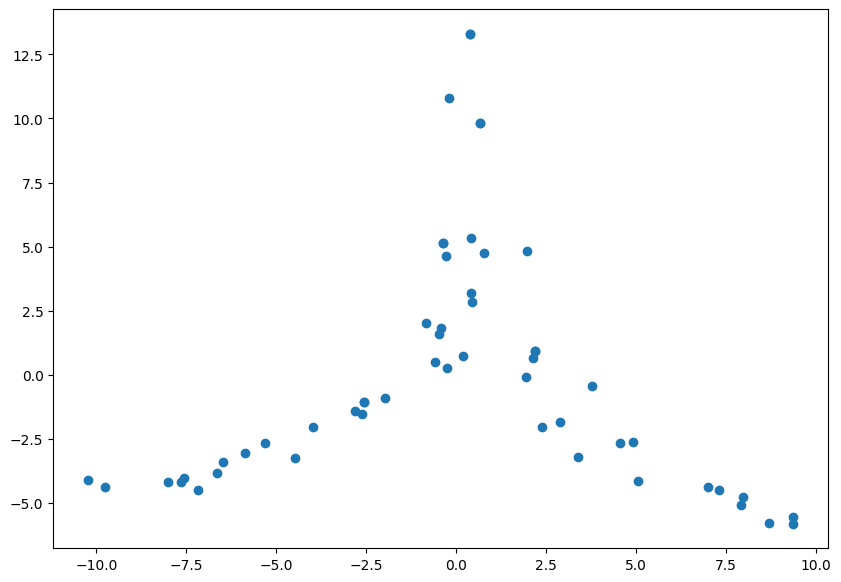

In [83]:
import time
from urllib.request import urlopen
from lxml import etree
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

id_list = []
with open("prace.txt", "r") as f:
    id_list = [line.strip() for line in f if line.strip()]

all_mesh_lists = []
base_efetch_url = "https://eutils.ncbi.nlm.nih.gov/entrez/eutils/efetch.fcgi?"

for pmid in id_list:
    fetch_query = "db=pubmed&id=" + pmid + "&format=xml"
    fetch_url = base_efetch_url + fetch_query
    
    fetch_response = urlopen(fetch_url)
    fetch_xml_data = fetch_response.read()
    fetch_xml = etree.XML(fetch_xml_data)
    
    mesh_elements = fetch_xml.xpath("//DescriptorName")
    current_mesh_list = [elem.text.lower() for elem in mesh_elements if elem.text is not None]
    all_mesh_lists.append(current_mesh_list)
    
    print(f"PMID {pmid} (MeSH): {current_mesh_list}")
    time.sleep(0.4)

mesh_list_list = [" ".join(mesh_list) for mesh_list in all_mesh_lists]

vectorizer = TfidfVectorizer()
X_tfidf = vectorizer.fit_transform(mesh_list_list)
X_tfidf_dense = X_tfidf.toarray()

sc = StandardScaler()
Xs = sc.fit_transform(X_tfidf_dense)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(Xs)

plt.figure(figsize=(10, 7))
plt.scatter(X_pca[:, 0], X_pca[:, 1], alpha=1)

plt.show()

**Nucleotide**

The Nucleotide database at NCBI is a public repository of nucleic acid sequences covering DNA and RNA from a variety of organisms, including genomes, genes, transcripts, and mitochondrial sequences.

In [ ]:
from urllib.request import urlopen
from lxml import etree

ID = 'U20285.2' # sequence id
baseurl = "https://eutils.ncbi.nlm.nih.gov/entrez/eutils/efetch.fcgi?"
query = "db=nucleotide&id="+ID+"&format=xml" 
url = baseurl+query

f = urlopen(url) 
resultxml = f.read() 
xml = etree.XML(resultxml) 

In [ ]:
tags = list({elem.tag for elem in xml.iter()}) # what can I learn about this sequence?

print(tags)

['GBSeq_other-seqids', 'GBSeq_strandedness', 'GBReference_reference', 'GBReference', 'GBSeq_length', 'GBSeq_primary-accession', 'GBReference_position', 'GBInterval_accession', 'GBSeq_locus', 'GBInterval_point', 'GBQualifier_name', 'GBFeature_key', 'GBSeq_references', 'GBInterval_from', 'GBSeq_sequence', 'GBSeq_definition', 'GBSeq_division', 'GBFeature', 'GBSeq_comment', 'GBSeq_source', 'GBAuthor', 'GBFeature_intervals', 'GBReference_remark', 'GBSeq', 'GBSeq_accession-version', 'GBQualifier', 'GBInterval_to', 'GBSeq_create-date', 'GBSet', 'GBSeq_moltype', 'GBReference_pubmed', 'GBFeature_quals', 'GBReference_title', 'GBReference_journal', 'GBSeq_topology', 'GBSeq_update-date', 'GBReference_authors', 'GBSeq_taxonomy', 'GBFeature_location', 'GBSeq_feature-table', 'GBQualifier_value', 'GBInterval', 'GBSeqid', 'GBSeq_organism']


In [ ]:
resultelements = xml.xpath("//GBSeq_sequence")

for element in resultelements:
    print(element.text)

tctctgaagttccagaatcgatggaagtggacggcacgccgcggcggggtgggtgcaagatgccgctgccggttcaggtgtttaacttgcagggggccgtggagcccatgcagatcgacgtggacccccaggaagacccgcagaatgcacctgacgtcaactacgtggtggagaaccccagcctggatctggaacagtacgcggccagctacagcggcctgatgcgcatcgaacggctgcagttcattgctgatcactgccccacgctgcgggtggaggccctgaagatggccctctccttcgtgcagagaacctttaacgtggacatgtacgaggagatccaccgcaagctctcagaggccaccagggagctgcagaacgcacccgacgccatccctgagagcggcgtggagcccccagccctggacacggcctgggtggaggccacgcggaagaaggcgctgctgaagctggagaagctggacacagacctgaagaactacaagggcaactccatcaaagagagcatccggcgcggccacgacgacctgggcgaccactacctggactgtggggacctcagcaacgccctcaagtgctattcccgggcccgggactactgcaccagcgccaaacacgtcatcaacatgtgcctcaatgtcatcaaggtcagcgtctacttgcagaattggtctcatgtgctcagctacgtcagcaaggctgagtccaccccagagattgccgagcagcgaggagagcgtgacagccagacccaggccatcctcaccaagctcaagtgtgccgcaggcttggcagagctggccgccaggaagtacaagcaggctgccaagtgcctcctgctggcttcctttgatcactgtgacttccctgagctgctgtcccccagcaacgtggccatctacggtggcctgtgcgccttggctacctttgaccggcaggagctgcagcgcaatgtcatctccagcagctccttcaagtt

### **Task 5**
    
Define a function that retrieves a number of records from Nucleotide and writes them to an external FASTA file, with the name in [GBSeq_definition] and the sequence in [GBSeq_sequence]. Test the operation of the function on: NM_001012006.1, MK560199.1, AB046569.1.

In [22]:
import time
from urllib.request import urlopen
from lxml import etree

def download_fasta(id_list, output_filename):
    
    base_url = "https://eutils.ncbi.nlm.nih.gov/entrez/eutils/efetch.fcgi?"

    with open(output_filename, "w", encoding="utf-8") as f:
        for seq_id in id_list:
            print(f"Downloading sequence for: {seq_id}")
            fetch_query = "db=nucleotide&id=" + seq_id + "&format=xml"
            fetch_url = base_url + fetch_query
            
            fetch_response = urlopen(fetch_url)
            fetch_xml_data = fetch_response.read()
            fetch_xml = etree.XML(fetch_xml_data)
            
            definition = fetch_xml.find(".//GBSeq_definition")
            sequence = fetch_xml.find(".//GBSeq_sequence")
            
            header = definition.text
            sequence = sequence.text.upper()
            
            f.write(f">{header}\n")
            
            for i in range(0, len(sequence), 80):
                f.write(sequence[i:i+80] + "\n")

            f.write("\n")

            time.sleep(0.4)

ids = ["NM_001012006.1", "MK560199.1", "AB046569.1"]
download_fasta(ids, "sequences.fasta")

**PubChem**

PubChem is an NCBI database containing mainly small chemical compounds along with their structures, physicochemical properties and biological data. It serves as an open source of information used in chemoinformatics, drug design and bioinformatics analyses.

*Visualization of the structure of chemical compounds based on the SMILES format:*

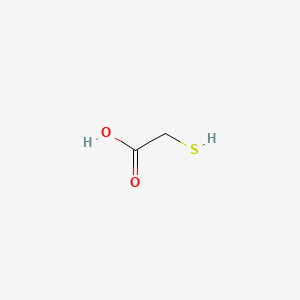

In [23]:
from urllib.request import urlretrieve
from IPython.display import Image

smiles = 'C(=O)(O)CS'
urlretrieve('https://pubchem.ncbi.nlm.nih.gov/rest/pug/compound/smiles/'+smiles+'/PNG', 'smi_pic.png')
p = Image(filename='smi_pic.png')
p

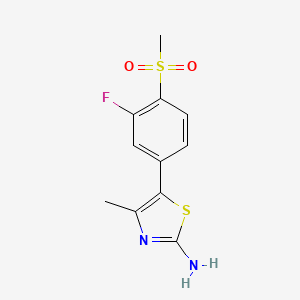

In [ ]:
from urllib.request import urlretrieve
from IPython.display import Image

smiles = 'NC1=NC(C)=C(C2=CC=C(S(=O)(C)=O)C(F)=C2)S1'
urlretrieve('https://pubchem.ncbi.nlm.nih.gov/rest/pug/compound/smiles/'+smiles+'/PNG', 'smi_pic.png')
p = Image(filename='smi_pic.png')
p

<h4> *Nazwa na podstawie SMILES

In [ ]:
import requests

def smiles_to_pubchem(smiles):
    url = f"https://pubchem.ncbi.nlm.nih.gov/rest/pug/compound/smiles/{smiles}/cids/JSON"
    response = requests.get(url).json()

    if "IdentifierList" not in response:
        print("No compound found for the given SMILES.")
        return None

    cid = response["IdentifierList"]["CID"][0]
    name_url = f"https://pubchem.ncbi.nlm.nih.gov/rest/pug/compound/cid/{cid}/property/IUPACName/JSON"
    name_response = requests.get(name_url).json()
    name = name_response["PropertyTable"]["Properties"][0].get("IUPACName", "brak nazwy")
    return name


# action example
print(smiles_to_pubchem("C1=NC2=NC=NC(=C2N1)N"))

7H-purin-6-amine


* Synonimy

In [ ]:
sm = "7H-purin-6-amine"
query = f"https://pubchem.ncbi.nlm.nih.gov/rest/pug/compound/name/{sm}/synonyms/XML"
response = urlopen(query)
resultxml = response.read()
tree = etree.XML(resultxml)
synonyms = []
for elem in tree.iter():
    if elem.tag == "{http://pubchem.ncbi.nlm.nih.gov/pug_rest}Synonym":
        synonyms.append(elem.text)
        
print(synonyms[:10])

['adenine', '73-24-5', '6-Aminopurine', '1H-Purin-6-amine', '7H-Purin-6-amine', 'Adenin', 'Adeninimine', 'Leuco-4', '6-Amino-1H-purine', '6-Amino-3H-purine']


**Retrieving the structure of chemical compounds and their physicochemical properties based on the name of the compound**

In [24]:
import requests

n = "adenine"
url = f"https://pubchem.ncbi.nlm.nih.gov/rest/pug/compound/name/{n}/property/CanonicalSMILES,MolecularWeight,XLogP,TPSA,HBondDonorCount,HBondAcceptorCount,RotatableBondCount/JSON"

response = requests.get(url).json()
props = response["PropertyTable"]["Properties"][0]

print("SMILES:", props["ConnectivitySMILES"])
print("Masa molowa:", float(props["MolecularWeight"])) #the mass is returned as a string, hence str -> float
print("logP (lipophilicity):", props["XLogP"])
print("Number of H donors:", props["HBondDonorCount"])
print("Number of H acceptors:", props["HBondAcceptorCount"])
print("Number of rotatable bonds:", props["RotatableBondCount"])
print("Powierzchnia TPSA:", props["TPSA"])

SMILES: C1=NC2=NC=NC(=C2N1)N
Masa molowa: 135.13
logP (lipophilicity): -0.1
Number of H donors: 2
Number of H acceptors: 4
Number of rotatable bonds: 0
Powierzchnia TPSA: 80.5


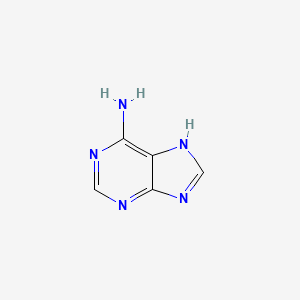

In [94]:
urlretrieve('https://pubchem.ncbi.nlm.nih.gov/rest/pug/compound/smiles/'+props["ConnectivitySMILES"]+'/PNG', 'smi_pic.png')
p = Image(filename='smi_pic.png')
p

### **Task 6**

- Download information about the structure of Lopinavir (HIV protease inhibitor) in SMILES format, visualize this molecule. 
- *(optional)* Based on the 1MUI record from the PDB, determine which amino acid residue of the HIV protease the lopinavir compound has the smallest distance from.
- Define a function that returns a list of physicochemical properties for a given compound (based on its name) - mass, logP, number of H donors, number of H acceptors, number of rotable bonds, TPSA surface area.
- Call the function for various HIV protease inhibitors and other drugs (not directly related to HIV protease), save the result as a list of lists.
- Standardize the data and then PCA with k=2. Visualize your results by coloring your observations by group. Comment on the received graph.

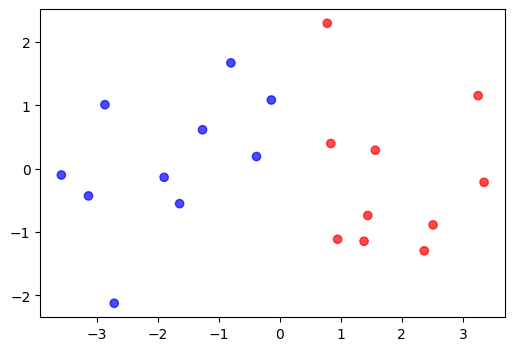

In [95]:
import requests
import time
from urllib.request import urlretrieve
from IPython.display import Image, display
from rdkit import Chem
from rdkit.Chem import Descriptors
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

hiv_protease_inhibitors = [
    "Lopinavir",
    "Ritonavir",
    "Saquinavir",
    "Indinavir",
    "Nelfinavir",
    "Atazanavir",
    "Darunavir",
    "Fosamprenavir",
    "Tipranavir",
    "Amprenavir"
]

non_inhibitors = [
    "Simvastatin",
    "Loratadine",
    "Omeprazole",
    "Maraviroc",
    "Diazepam",
    "Captopril",
    "Naproxen",
    "Losartan",
    "Fexofenadine",
    "Celecoxib"
]

drug_name = "Lopinavir"

url_smiles = f"https://pubchem.ncbi.nlm.nih.gov/rest/pug/compound/name/{drug_name}/property/CanonicalSMILES/JSON"
response_smiles = requests.get(url_smiles).json()

smiles = response_smiles["PropertyTable"]["Properties"][0]["ConnectivitySMILES"]

png_filename = f"{drug_name}.png"
url_png = f'https://pubchem.ncbi.nlm.nih.gov/rest/pug/compound/smiles/{smiles}/PNG'
urlretrieve(url_png, png_filename)

def get_properties_from_smiles(smiles):
    mol = Chem.MolFromSmiles(smiles)
    
    props = [
        Descriptors.MolWt(mol),
        Descriptors.MolLogP(mol),
        Descriptors.NumHDonors(mol),
        Descriptors.NumHAcceptors(mol),
        Descriptors.NumRotatableBonds(mol),
        Descriptors.TPSA(mol)
    ]
    return props

all_data = []
all_labels = []

for name in hiv_protease_inhibitors:
    url = f"https://pubchem.ncbi.nlm.nih.gov/rest/pug/compound/name/{name}/property/CanonicalSMILES/JSON"
    response = requests.get(url).json()
    
    smiles = response["PropertyTable"]["Properties"][0]["ConnectivitySMILES"]
    
    props = get_properties_from_smiles(smiles)
    all_data.append(props)
    all_labels.append("Inhibitor")
    time.sleep(0.5) 

for name in non_inhibitors:
    url = f"https://pubchem.ncbi.nlm.nih.gov/rest/pug/compound/name/{name}/property/CanonicalSMILES/JSON"
    response = requests.get(url).json()
    
    smiles = response["PropertyTable"]["Properties"][0]["ConnectivitySMILES"]
    
    props = get_properties_from_smiles(smiles)
    all_data.append(props)
    all_labels.append("Non-Inhibitor")
    time.sleep(0.5)

X = all_data 

sc = StandardScaler()
Xs = sc.fit_transform(X)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(Xs)

plt.figure(figsize=(6, 4))
colors = ["red" if label == "Inhibitor" else "blue" for label in all_labels]
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=colors, alpha=0.7)

plt.scatter([], [], c="red", label="Inhibitor")
plt.scatter([], [], c="blue", label="Non-Inhibitor")

plt.show()

**TF-IDF**

In [25]:
documents = ["new york times", "new york post", "los angeles times"]
N = len(documents)

In [ ]:
import binf2 as b
import pandas as pd

df = b.TFIDF(documents, True)
print(df)

In [99]:
new_doc = {'los': 0.0,
 'york': 0.0,
 'post': 0.0,
 'angeles': 0.0,
 'new': 0.5849625007211562,
 'times': 0.2924812503605781}

In [100]:
df2 = pd.concat([df, pd.DataFrame([new_doc])], ignore_index=True)
print(df2)

       post       new       los     times      york   angeles
0  0.000000  0.584963  0.000000  0.584963  0.584963  0.000000
1  1.584963  0.584963  0.000000  0.000000  0.584963  0.000000
2  0.000000  0.000000  1.584963  0.584963  0.000000  1.584963
3  0.000000  0.584963  0.000000  0.292481  0.000000  0.000000


**Standardization + PCA**

In [ ]:
from sklearn.preprocessing import StandardScaler 
sc = StandardScaler() #data standardization
Xs = sc.fit_transform(df2)

from sklearn.decomposition import PCA
pca = PCA(n_components=2)
pca.fit(Xs)
X_pca = pca.transform(Xs)

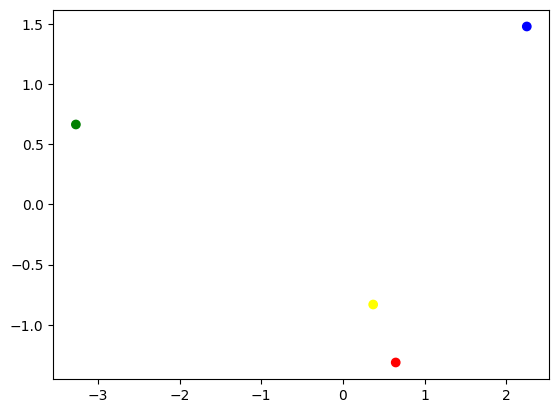

In [102]:
import matplotlib.pyplot as plt # library for drawing plots
plt.scatter(X_pca[:, 0], X_pca[:, 1], alpha=1, c = ["red", "blue", "green", "yellow"])
plt.show()

**RDKit**

RDKit is an open-source chemoinformatics library for Python that allows you to analyze and manipulate chemical structures, calculate physicochemical properties, generate descriptors, and work with SMILES, Mol, and other molecule formats. RDKit counts properties based on chemical structure, i.e. SMILES, Mol or other representations of the molecule.

In [28]:
from rdkit import Chem
from rdkit.Chem import Descriptors

smiles ="C1=NC2=NC=NC(=C2N1)N"
mol = Chem.MolFromSmiles(smiles)

# property calculation
masa_mol = Descriptors.MolWt(mol)
logp = Descriptors.MolLogP(mol)
h_donors = Descriptors.NumHDonors(mol)
h_acceptors = Descriptors.NumHAcceptors(mol)
rot_bonds = Descriptors.NumRotatableBonds(mol)
tpsa = Descriptors.TPSA(mol)

print(f"Molar mass: {masa_mol}")
print(f"logP (lipophilicity): {logp}")
print(f"Number of H donors: {h_donors}")
print(f"Number of H acceptors: {h_acceptors}")
print(f"Number of rotatable bonds: {rot_bonds}")
print(f"Powierzchnia TPSA: {tpsa}")

Molar mass: 135.12999999999997
logP (lipophilicity): -0.06490000000000001
Number of H donors: 2
Number of H acceptors: 4
Number of rotatable bonds: 0
Powierzchnia TPSA: 80.48


**Biopython**

In [3]:
from Bio import Entrez
Entrez.email = "your.email@example.com"
handle = Entrez.efetch(db="nucleotide", id="278554061", rettype="fasta", retmode="text")
record = handle.read()
print(record)
handle.close()

>DAAB012401936.1 TPA_asm: Homo sapiens contig2401936, whole genome shotgun sequence
ACGTCGTCTAATTCTGATACTCTGTAGCCATTAAACAGTAGCTCCCTATTTCCTCCTCTCCCCAGCCCTG
ACAGTCATCATTCTACTTTCTGTTCCTGTGATTTGGCTATTTTAGGTATCCCATATAAGTGGAGTCATAC
AATATT


